# Эксперимент 13: HuBERT + LSTM + классификатор

**Статья:** Hybrid-Module Transformer: enhancing speech emotion recognition with HuBERT, LSTM, and ResNet-50 (Гибридный модульный Transformer: улучшение распознавания речевых эмоций с HuBERT, LSTM и ResNet-50) 2024

**Ссылка:** [https://peerj.com/articles/cs-3292/](https://peerj.com/articles/cs-3292/)

**Краткое описание модели:** HuBERT-эмбеддинги как высокоуровневые признаки -> BiLSTM/FC голова для бинарной классификации.

**Содержание статьи:** Статья показывает, что HuBERT хорошо извлекает информативные речевые представления для downstream задач. Добавление рекуррентного модуля улучшает учет темпорального контекста. Несмотря на исходную задачу эмоций, архитектурный паттерн переносим на диагностику дефектной речи.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import time
import torch
from torch.utils.data import DataLoader
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils
from shared.results_utils import save_result_csv
from model import get_model

## 1. Разбиение и датасет по waveform

In [ ]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

SR = config.TARGET_SR
MAX_SEC = config.MAX_DURATION_SEC
MAX_LEN = int(SR * MAX_SEC)

def load_waveform(path):
    y, _ = data_utils.load_audio(path, sr=SR, max_sec=MAX_SEC)
    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)), mode="constant", constant_values=0)
    else:
        y = y[:MAX_LEN]
    return y.astype(np.float32)

class WaveformDataset(torch.utils.data.Dataset):
    def __init__(self, paths, labels, letters):
        self.paths = paths
        self.labels = labels
        self.letters = letters
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        wav = load_waveform(self.paths[i])
        let = torch.from_numpy(self.letters[i].astype(np.float32))
        return torch.from_numpy(wav), let, self.labels[i]

train_ds = WaveformDataset(paths_train, y_train, letters_train)
val_ds   = WaveformDataset(paths_val, y_val, letters_val)
test_ds  = WaveformDataset(paths_test, y_test, letters_test)
print(f"Длина waveform: {MAX_LEN} сэмплов ({MAX_SEC} с)")

## 2. DataLoader и модель

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Device: cuda


In [4]:
model = get_model(num_classes=2, n_letters=n_letters, dropout=0.3, freeze_encoder=True, lstm_hidden=128).to(device)
n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров: {n_params}, обучаемых: {n_trainable}")

I0000 00:00:1774501668.046684 1206249 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Параметров: 95291794, обучаемых: 920082


## 3. Обучение

In [5]:
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [6]:
def eval_loader(loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, letters, y in loader:
            x, letters, y = x.to(device), letters.to(device), y.to(device)
            logits = model(x, letters=letters)
            pred = logits.argmax(dim=1)
            all_pred.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    return np.concatenate(all_pred), np.concatenate(all_true)

N_EPOCHS = 50
train_losses, val_f1s = [], []

t0 = time.perf_counter()
for epoch in range(N_EPOCHS):
    model.train()
    epoch_losses = []
    for x, letters, y in train_loader:
        x, letters, y = x.to(device), letters.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x, letters=letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(np.mean(epoch_losses))
    vp, vt = eval_loader(val_loader)
    val_f1 = f1_score(vt, vp, average="macro")
    val_f1s.append(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  train_loss={train_losses[-1]:.4f}  val_f1_macro={val_f1:.4f}")
train_time_sec = time.perf_counter() - t0
print(f"Обучение заняло {train_time_sec:.1f} с.")

Epoch 1/50  train_loss=0.5737  val_f1_macro=0.7987
Epoch 2/50  train_loss=0.5092  val_f1_macro=0.7998
Epoch 3/50  train_loss=0.4777  val_f1_macro=0.8044
Epoch 4/50  train_loss=0.4500  val_f1_macro=0.8148
Epoch 5/50  train_loss=0.4059  val_f1_macro=0.7944
Epoch 6/50  train_loss=0.3841  val_f1_macro=0.8140
Epoch 7/50  train_loss=0.3555  val_f1_macro=0.7895
Epoch 8/50  train_loss=0.3193  val_f1_macro=0.7779
Epoch 9/50  train_loss=0.2922  val_f1_macro=0.7879
Epoch 10/50  train_loss=0.2558  val_f1_macro=0.7672
Epoch 11/50  train_loss=0.2312  val_f1_macro=0.7919
Epoch 12/50  train_loss=0.2174  val_f1_macro=0.7905
Epoch 13/50  train_loss=0.1870  val_f1_macro=0.7600
Epoch 14/50  train_loss=0.1381  val_f1_macro=0.7445
Epoch 15/50  train_loss=0.1437  val_f1_macro=0.7772
Epoch 16/50  train_loss=0.1149  val_f1_macro=0.7856
Epoch 17/50  train_loss=0.0892  val_f1_macro=0.7660
Epoch 18/50  train_loss=0.0627  val_f1_macro=0.7625
Epoch 19/50  train_loss=0.0904  val_f1_macro=0.7794
Epoch 20/50  train_lo

## 4. Оценка на тесте и метрики

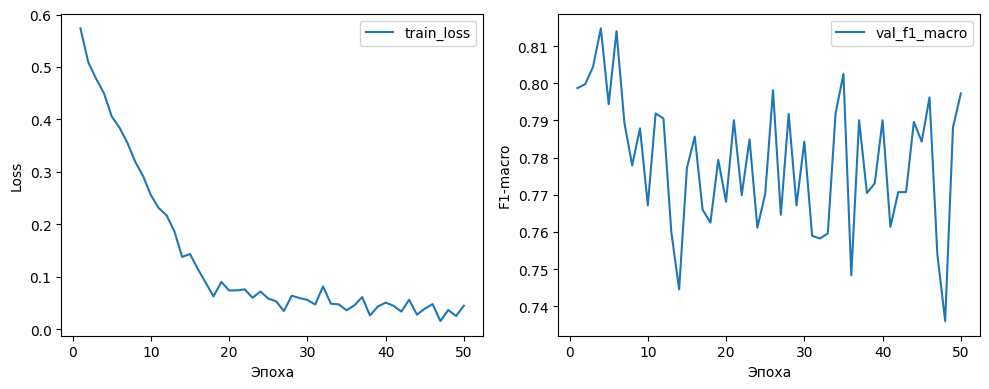

In [7]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, N_EPOCHS + 1), val_f1s, label="val_f1_macro")
plt.xlabel("Эпоха")
plt.ylabel("F1-macro")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
model.eval()
all_logits = []
with torch.no_grad():
    for x, letters, _ in test_loader:
        x, letters = x.to(device), letters.to(device)
        all_logits.append(model(x, letters=letters).cpu().numpy())
logits = np.concatenate(all_logits)
y_pred = np.argmax(logits, axis=1)
y_proba = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

metrics_table = pd.DataFrame([{
    "accuracy": accuracy, "f1_macro": f1_macro, "f1_bad": f1_bad,
    "roc_auc": roc_auc, "precision_bad": precision_bad, "recall_bad": recall_bad,
}])
print("\nТаблица метрик (тест):")
display(metrics_table)

              precision    recall  f1-score   support

        good       0.80      0.93      0.86       282
         bad       0.78      0.53      0.63       135

    accuracy                           0.80       417
   macro avg       0.79      0.73      0.75       417
weighted avg       0.80      0.80      0.79       417

Accuracy: 0.7986
F1 macro: 0.7451
F1 (bad): 0.6283
ROC-AUC:  0.8232

Таблица метрик (тест):


,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.798561,0.74508,0.628319,0.823207,0.78022,0.525926


## 5. Запись метрик в общий файл

In [ ]:
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_13_hubert",
    experiment_name="HuBERT + LSTM",
    model="HubertLSTMClassifier",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes="facebook/hubert-base-ls960, encoder frozen, BiLSTM 128, 10s",
    num_params=n_params,
    train_time_sec=train_time_sec,
)